<a href="https://colab.research.google.com/github/priyavarshini04/Dual-Prediction-of-Blood-Pressure-and-Blood-Glucose-Level-using-PPG-Signals/blob/main/BaseLineBPmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mkachuee/BloodPressureDataset")

print("Path to dataset files:", path)

100%|██████████| 4.60G/4.60G [00:45<00:00, 109MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mkachuee/BloodPressureDataset/versions/5


In [ ]:
# importing libraries
import numpy as np # For numerical computation
import pandas as pd # Data manipulation
import seaborn as sns # plotting
import scipy.io # reading matlab files in python
from scipy import signal #signal processing
from scipy.fftpack import fft, dct #signal processing

from sklearn.linear_model import LinearRegression #linear regression model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split # cross validation split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from matplotlib import pyplot as plt # For plotting graphs(Visualization)

import os # system-wide functions
os.listdir('/root/.cache/kagglehub/datasets/mkachuee/BloodPressureDataset/versions/5')

['part_7.mat',
 'part_6.mat',
 'part_4.mat',
 'part_3.mat',
 'part_11.mat',
 'part_1.mat',
 'part_5.mat',
 'part_8.mat',
 'part_12.mat',
 'part_2.mat',
 'part_10.mat',
 'part_9.mat',
 'Samples']

In [ ]:
sample_file = scipy.io.loadmat(f'/root/.cache/kagglehub/datasets/mkachuee/BloodPressureDataset/versions/5/part_{1}.mat')
print(f'sample_file Data type: {type(sample_file)}')
print(f'sample_file keys:\n{sample_file.keys()}')

sample_file Data type: <class 'dict'>
sample_file keys:
dict_keys(['__header__', '__version__', '__globals__', 'p'])


We use the scipy.io.loadmat() method to read our sample matlab(.mat) file and store it in the variable sample_file

The scipy.io.loadmat() method reads the matlab file and returns a dict/(dictionary) which is then stored back in the sample_file variable. To prove this, we print the data type of sample_file type(sample_file) as seen in line-2 and bingo it tells us its a dict
A dictionary is a data structure that stores data in key, value pairs. For instance; {key1: value1, key2: value2}. What line-3 in the cell above does is to get and return the keys of the sample_file dictionary.

From what we've seen above, we only need the values contained in the key p (photoplethysmograph or (PPG)). The other keys contain meta data that we won't need. Therefore in all other cells I'll apply ['p'] at the end of the .loadmat() method to only read the values contained in the key ['p']i.e scipy.io.loadmat(f'../input/BloodPressureDataset/part_{1}.mat')['p']

In [ ]:
# Loading a sample .mat file to understand the data dimensions
test_sample = scipy.io.loadmat(f'/root/.cache/kagglehub/datasets/mkachuee/BloodPressureDataset/versions/5/part_{1}.mat')['p']
print(f'test_sample Data type: {type(test_sample)}')
print(f'test_sample shape/dimensions: {test_sample.shape}')

test_sample Data type: <class 'numpy.ndarray'>
test_sample shape/dimensions: (1, 1000)


We use the scipy.io.loadmat() method to read our sample matlab(.mat) file and store it in the variable test_sample
The scipy.io.loadmat() method reads the matlab file and this time around returns a numpy ndarray (because of the ['p']) which is then stored in the test_sample variable. To prove this, we print the data type of test_sample type(test_sample) as seen in line-2 and bingo it tells us its numpy.ndarray (nd means n-dimensional)
Additionally, we check and print the size/dimensions of test_sample by running test_sample.shape and it prints out (1,1000); this means the array contains 1 row and 1000 columns.

In [ ]:
print(f"Total Samples: {len(test_sample[0])}")
print(f"Number of readings in each sample(column): {len(test_sample[0][0])}")
print(f"Number of samples in each reading(ECG): {len(test_sample[0][0][2])}")

temp_mat = test_sample[0, 999]
temp_length = temp_mat.shape[1]
sample_size = 125


print(temp_length)
print((int)(temp_length/sample_size))

Total Samples: 1000
Number of readings in each sample(column): 3
Number of samples in each reading(ECG): 61000
9000
72


In [ ]:
sample_size = 125
ppg = []
for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ppg = temp_mat[0, j*sample_size:(j+1)*sample_size]
        ppg.append(temp_ppg)

In [ ]:
ecg = []
bp = []
sbp = [] #Systolic Blood Pressure
dbp = [] #Diastolic Blood Pressue
size = 125 #sample size

for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ecg = temp_mat[2, j*size:(j+1)*size]
        temp_bp = temp_mat[1, j*size:(j+1)*size]

        max_value = max(temp_bp)
        min_value = min(temp_bp)

        sbp.append(max_value)
        dbp.append(min_value)
        ecg.append(temp_ecg)
        bp.append(temp_bp)

In [ ]:
# Assuming the loop has been run and the lists are populated

# Print the first few values in each list
print("First few values in sbp:", sbp[:5])  # Print first 5 values in sbp
print("First few values in dbp:", dbp[:5])  # Print first 5 values in dbp
print("First few values in ecg:", ecg[:5])  # Print first 5 chunks of ECG data
print("First few values in bp:", bp[:5])    # Print first 5 chunks of BP data

First few values in sbp: [np.float64(124.6013099988766), np.float64(120.98684628271945), np.float64(122.35448120234648), np.float64(122.74523403652563), np.float64(125.18743925014532)]
First few values in dbp: [np.float64(66.52567001900036), np.float64(65.59763203782488), np.float64(66.1349171848212), np.float64(67.0629551659967), np.float64(67.50255210444824)]
First few values in ecg: [array([-0.06060606, -0.07526882, -0.07038123, -0.03519062,  0.02443793,
        0.08993157,  0.15493646,  0.20478983,  0.24975562,  0.27468231,
        0.29472141,  0.30498534,  0.30987292,  0.31964809,  0.31964809,
        0.32502444,  0.32502444,  0.32502444,  0.32502444,  0.31964809,
        0.31964809,  0.32991202,  0.35483871,  0.36999022,  0.39002933,
        0.42473118,  0.45014663,  0.4599218 ,  0.42473118,  0.3597263 ,
        0.28983382,  0.25464321,  0.24975562,  0.24975562,  0.23998045,
        0.24486804,  0.42473118,  0.99022483,  1.4457478 ,  1.07038123,
        0.3797654 ,  0.09481916,  

I extract BP and ECG signals from the mat file and store them in an array/list.

I additionally extract Systolic blood pressure(SBP) and Diastolic Blood pressure(DBP) from the BP signal.

systole and diastole are two phases of a heart beat. BP increases as the heart muscle contracts during systole, where blood is pushed towards the periphery of the body and it decreases when the heart relaxes to fill with blood during the diastole. Hence we take max(BP) to derive SBP and min(BP) to get DBP.

In [ ]:
# Reshaping the ecg, ppg and bp signal data into column vectors
ppg, ecg, bp = np.array(ppg).reshape(-1,1), np.array(ecg).reshape(-1,1), np.array(bp).reshape(-1,1)
sbp, dbp = np.array(sbp).reshape(-1,1), np.array(dbp).reshape(-1,1)
print(f'PPG_shape: {ppg.shape}\n ECG_shape: {ecg.shape}\n BP_shape: {bp.shape}')
print(f'Systolic-BP_shape: {sbp.shape},\n Diastolic-BP_shape: {dbp.shape}')

PPG_shape: (32061000, 1)
 ECG_shape: (32061000, 1)
 BP_shape: (32061000, 1)
Systolic-BP_shape: (256488, 1),
 Diastolic-BP_shape: (256488, 1)


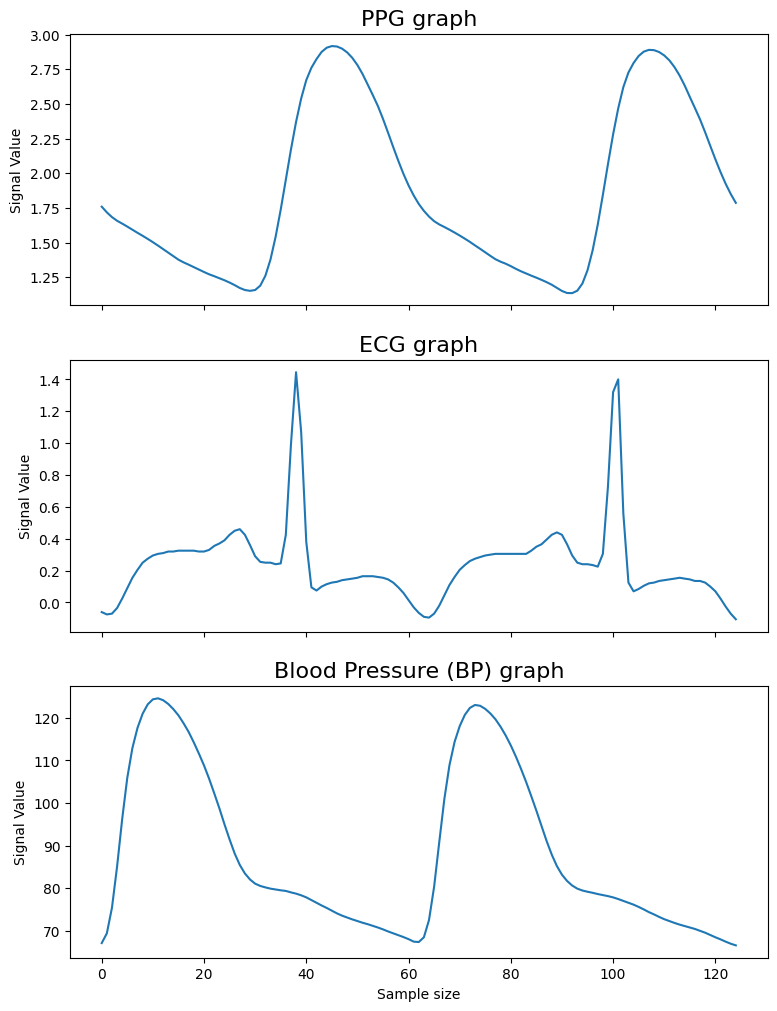

In [ ]:
##plotting sample ppg, ecg and bp signals
##using a sample size of 125
fig, ax = plt.subplots(3,1, figsize=(9,12), sharex=True)

ax[0].set_title('PPG graph', fontsize=16)
ax[0].set_ylabel('Signal Value')
ax[0].plot(ppg[:125])

ax[1].set_title('ECG graph', fontsize=16)
ax[1].set_ylabel('Signal Value')
ax[1].plot(ecg[:125])

ax[2].set_title('Blood Pressure (BP) graph', fontsize=16)
ax[2].set_ylabel('Signal Value')
ax[2].set_xlabel('Sample size')
ax[2].plot(bp[:125])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import xgboost as xgb
from sklearn.metrics import mean_squared_error


In [ ]:
# creating train and test sets
X_train, X_test, y_train, y_test = train_test_split(ppg, bp, test_size=0.30)

In [ ]:
# Train LSTM model for feature extraction
lstm_model = Sequential()
# Reshape X_train if it's a 2D array (samples, features) to (samples, timesteps, features)
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))  # (samples, timesteps, features)
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))  # Same for X_test
lstm_model.add(LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), return_sequences=False))
#lstm_model.add(LSTM(64, input_shape=(X_train_reshaped [1], X_test_reshaped[2]), return_sequences=False))
lstm_model.add(Dense(1))  # BP output

lstm_model.compile(optimizer=Adam(), loss='mean_squared_error')
lstm_model.fit(X_train[:1000000], y_train[:1000000], epochs=1, batch_size=128, validation_data=(X_test[:1000000], y_test[:1000000]))

# Extract LSTM features for XGBoost
lstm_features_train = lstm_model.predict(X_train[:1000000])
lstm_features_test = lstm_model.predict(X_test[:1000000])

# Combine the LSTM features with original PPG data for boosting
X_train_combined = np.hstack((X_train[:1000000], lstm_features_train))
X_test_combined = np.hstack((X_test[:1000000], lstm_features_test))

# Train XGBoost on combined features
dtrain = xgb.DMatrix(X_train_combined, label=y_train[:1000000])
dtest = xgb.DMatrix(X_test_combined, label=y_test[:1000000])

params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.1,
    'eval_metric': 'rmse'
}

model = xgb.train(params, dtrain, num_boost_round=500, early_stopping_rounds=50, evals=[(dtest, 'eval')])

y_pred = model.predict(dtest)
rmse = np.sqrt(mean_squared_error(y_test[:1000000], y_pred[:1000000]))
print(f"Hybrid Model (LSTM + XGBoost) RMSE: {rmse}")


7813/7813 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 2879.2666 - val_loss: 807.4653
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 46s 1ms/step
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 46s 1ms/step
[0]	eval-rmse:27.76562
[1]	eval-rmse:27.32217
[2]	eval-rmse:26.95723
[3]	eval-rmse:26.65793
[4]	eval-rmse:26.41260
[5]	eval-rmse:26.21198
[6]	eval-rmse:26.04847
[7]	eval-rmse:25.91512
[8]	eval-rmse:25.80626
[9]	eval-rmse:25.71761
[10]	eval-rmse:25.64550
[11]	eval-rmse:25.58681
[12]	eval-rmse:25.53916
[13]	eval-rmse:25.50029
[14]	eval-rmse:25.46878
[15]	eval-rmse:25.44312
[16]	eval-rmse:25.42227
[17]	eval-rmse:25.40526
[18]	eval-rmse:25.39142
[19]	eval-rmse:25.38018
[20]	eval-rmse:25.37104
[21]	eval-rmse:25.36363
[22]	eval-rmse:25.35757
[23]	eval-rmse:25.35264
[24]	eval-rmse:25.34864
[25]	eval-rmse:25.34540
[26]	eval-rmse:25.34274
[27]	eval-rmse:25.34055
[28]	eval-rmse:25.33880
[29]	eval-rmse:25.33738
[30]	eval-rmse:25.33619
[31]	eval-rmse:25.33523
[32]	eval-rmse:25.33445
[33]	eval-rmse:25.33380
[34]	eval-rmse:25.3

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test[:1000000], y_pred[:1000000]))
print(f"Hybrid Model (LSTM + XGBoost) RMSE: {rmse}")

Hybrid Model (LSTM + XGBoost) RMSE: 25.33124172790031


In [ ]:
# Assuming your model is already defined as 'model1'
#model.save('/content/bp_model.h5')  # Save with a new name
model.save_model('/content/bp_model.json')  # or .model


In [ ]:
from tensorflow.keras.models import load_model
import xgboost as xgb
import numpy as np

# Load the glucose model (TensorFlow/Keras)
#model_glucose = load_model('/content/glucose_model.h5')  # Glucose prediction model (LSTM or similar)

# Load the BP model (XGBoost)
model_bp = xgb.Booster()
model_bp.load_model('/content/bp_model.json')

# Check expected input shape for glucose model (Keras only)
#print(f"Expected input shape for glucose model: {model_glucose.input_shape}")

# Prepare input samples
#single_sample_glucose = X_test[0].reshape(1, 2142, 1)  # For LSTM-style glucose model
single_sample_bp = X_test[0].reshape(1, -1)            # XGBoost expects 2D input (samples, features)

# Predict with glucose model
#glucose_prediction = model_glucose.predict(single_sample_glucose)

# Predict with BP model (using Booster's predict)
bp_prediction = model_bp.predict(xgb.DMatrix(single_sample_bp))

# Print predictions
#print(f"Predicted Glucose: {glucose_prediction[0]}")
print(f"Predicted BP: {bp_prediction[0]}")

# Compare to actual values
#actual_glucose = y_test[0][0]  # Adjust based on your y_test shape
actual_bp = y_test[0]    # Assuming BP is the second value

#print(f"Actual Glucose: {actual_glucose}")
print(f"Actual BP: {actual_bp}")


Predicted BP: 108.01000213623047
Actual BP: [68.63566827]


In [ ]:
import xgboost as xgb
import numpy as np

# Load the BP model
model_bp = xgb.Booster()
model_bp.load_model('/content/bp_model.json')

# Predict for first 50 samples
for i in range(50):
    sample_bp = X_test[i].reshape(1, -1)
    pred_bp = model_bp.predict(xgb.DMatrix(sample_bp))[0]
    true_bp = y_test[i]

    print(f"Sample {i+1}: Predicted BP = {pred_bp:.2f}, Actual BP = {true_bp.item():.2f}")



Sample 1: Predicted BP = 108.01, Actual BP = 68.64
Sample 2: Predicted BP = 79.54, Actual BP = 61.69
Sample 3: Predicted BP = 109.65, Actual BP = 121.67
Sample 4: Predicted BP = 90.29, Actual BP = 98.57
Sample 5: Predicted BP = 80.11, Actual BP = 64.47
Sample 6: Predicted BP = 80.39, Actual BP = 80.33
Sample 7: Predicted BP = 82.96, Actual BP = 66.28
Sample 8: Predicted BP = 80.65, Actual BP = 118.11
Sample 9: Predicted BP = 117.13, Actual BP = 138.27
Sample 10: Predicted BP = 97.34, Actual BP = 60.33
Sample 11: Predicted BP = 84.20, Actual BP = 82.45
Sample 12: Predicted BP = 114.39, Actual BP = 150.40
Sample 13: Predicted BP = 119.56, Actual BP = 148.00
Sample 14: Predicted BP = 88.25, Actual BP = 57.32
Sample 15: Predicted BP = 79.49, Actual BP = 63.94
Sample 16: Predicted BP = 88.27, Actual BP = 74.56
Sample 17: Predicted BP = 79.64, Actual BP = 81.30
Sample 18: Predicted BP = 79.49, Actual BP = 73.22
Sample 19: Predicted BP = 81.61, Actual BP = 60.81
Sample 20: Predicted BP = 80.2

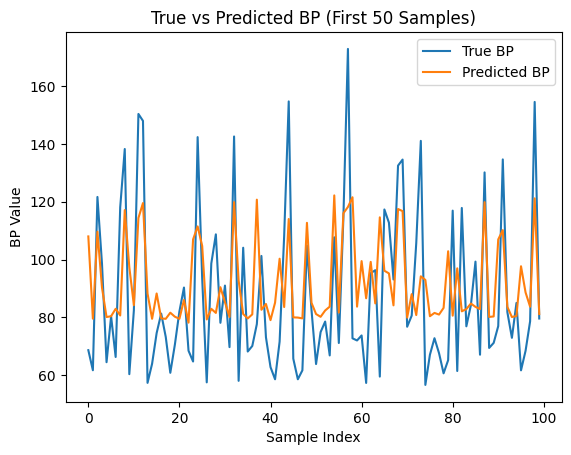

In [ ]:
import matplotlib.pyplot as plt

# Predict and collect values
predicted_bp = [model_bp.predict(xgb.DMatrix(X_test[i].reshape(1, -1)))[0] for i in range(100)]
true_bp = [y_test[i].item() for i in range(100)]

# Plot
plt.plot(true_bp, label='True BP')
plt.plot(predicted_bp, label='Predicted BP')
plt.title("True vs Predicted BP (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("BP Value")
plt.legend()
plt.show()
